
Ce notebook centralise le traitement des annotations manuelles réalisées par l'équipe sur les articles de presse. Il permet de :
1. **Extraire** les données brutes depuis les fichiers JSON individuels.
2. **Analyser** l'accord inter-annotateurs (Kappas) et la répartition des thématiques.
3. **Filtrer et Exporter** les datasets validés ("Gold Standards") selon différents scénarios (Majorité vs Unanimité).
4. **Générer** une feuille de route ciblée (Active Learning) pour résoudre les conflits d'annotation.

In [1]:
import os
print("Le Notebook cherche les fichiers dans ce dossier :")
print(os.getcwd())
%load_ext autoreload
%autoreload 2

from extractiondes_donneees import *
from analyse_de_donnees import *
from simuler_filtre import *
from assigner_donnees import *

fichiers_equipe = {
    "Hugo": "vldbench_batch_01 (1).json",
    "Eugene": "vldbench_batch_01 (2).json",
    "Kwabena": "vldbench_batch_01 (3).json",
    "Amadou": "vldbench_batch_01 (4).json",
    "Guillaume": "vldbench_batch_01 (5).json"
}


Le Notebook cherche les fichiers dans ce dossier :
c:\Users\user\Desktop\stage\dataset\18-05-2026


⏳ Extraction des données en cours...
Extraction terminée : 582 annotations récupérées au total.

       📊 RAPPORT D'ANALYSE DU DATASET (AI4Debunk)

1. DISTRIBUTION DES SCORES (Pourcentages globaux) :
   - Not_Related : 65.6%
   - Undetermined : 19.4%
   - Supporting : 14.3%
   - Against : 0.7%

2. RÉPARTITION PAR CATÉGORIE (TOPICS) :
   - Nombre total de topics uniques détectés : 13


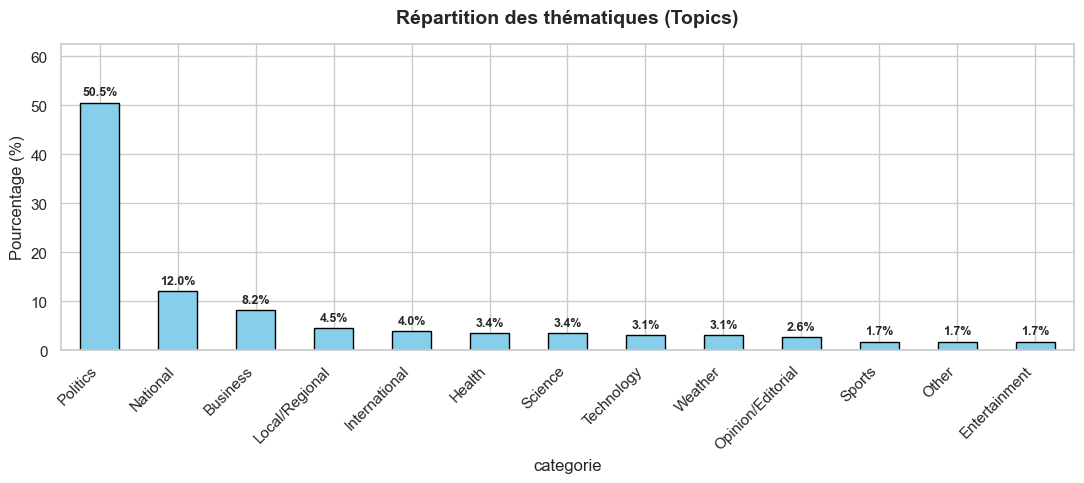


3. KAPPA DE COHEN (Analyse croisée deux à deux) :


,Paire,Articles communs,Kappa,Interprétation
0,Amadou & Eugene,120,0.670,Accord fort
1,Amadou & Guillaume,102,0.644,Accord fort
2,Amadou & Hugo,120,0.612,Accord fort
3,Amadou & Kwabena,120,0.538,Accord modéré
4,Eugene & Guillaume,102,0.760,Accord fort
5,Eugene & Hugo,120,0.683,Accord fort
6,Eugene & Kwabena,120,0.716,Accord fort
7,Guillaume & Hugo,102,0.615,Accord fort
8,Guillaume & Kwabena,102,0.575,Accord modéré
9,Hugo & Kwabena,120,0.520,Accord modéré


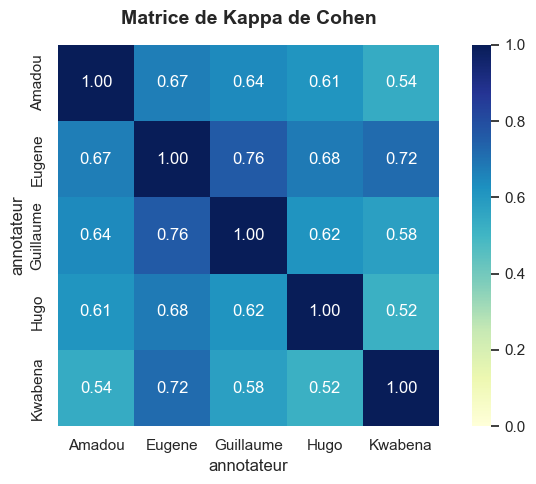


4. KAPPA DE FLEISS (Accord global des annotateurs) :
   👉 Score Fleiss Global : 0.561 (Accord modéré)

5. TYPOLOGIE DES ANNOTATIONS :


,Typologie,Nombre de cas
3,Unanimité (5-0),66
2,Majorité faible (3-2),24
0,Accord Majoritaire (4/4),15
1,Majorité forte (4-1),11
4,Accord Majoritaire (3/4),2
5,Désaccord / Division,1
6,Désaccord profond,1


c:\Users\user\Desktop\stage\dataset\18-05-2026\analyse_de_donnees.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_typo, x='Typologie', y='Nombre de cas', palette='Blues_r')


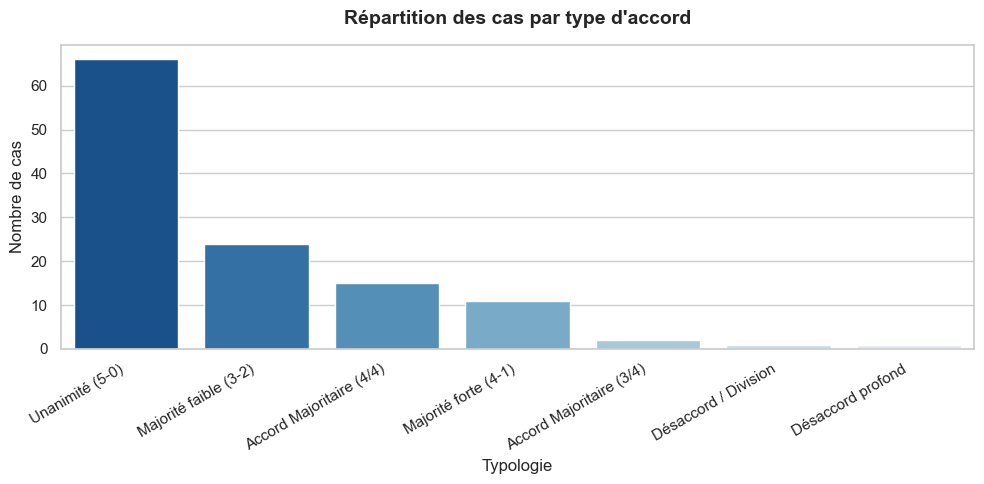


6. ANALYSE LEAVE-ONE-OUT (Impact de chaque annotateur sur le Fleiss) :


,Annotateur retiré,Nouveau Fleiss,Différence
0,Amadou,0.555,-0.006
1,Eugene,0.500,-0.061
2,Guillaume,0.623,+0.062
3,Hugo,0.558,-0.003
4,Kwabena,0.571,+0.010



7. ANALYSE DES SCORES DE SIMILARITÉ (Numérique) :
   👉 Corrélation de Pearson (Moyenne) : 1.000 (Forte corrélation)


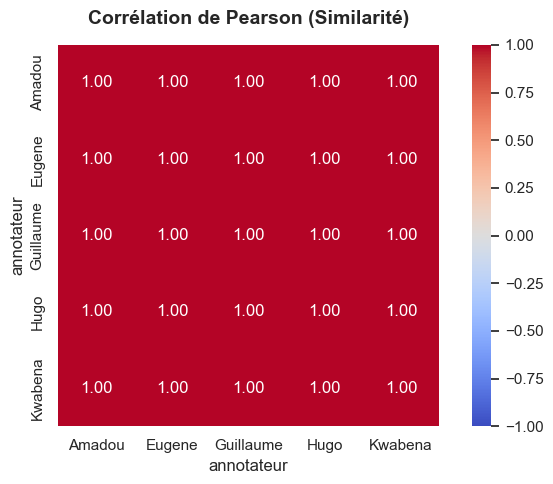

In [2]:

dataset = extraire_donnees(fichiers_equipe)

if dataset is not None and not dataset.empty: 
    # Étape B : Analyse descriptive et Kappas
    rapport_stats = analyser_donnees(dataset)

## Étape 3 : Simulation des Filtres et Création du Gold Standard
Pour entraîner l'IA, nous devons consolider les annotations individuelles en un label unique. Nous comparons ici deux scénarios :
1. **La Majorité Stricte (>50%)** : Préserve les classes minoritaires.
2. **L'Unanimité (100%)** : Qualité parfaite, mais risque de déséquilibrer massivement le dataset.

L'algorithme émettra une recommandation automatique et exportera les fichiers CSV nettoyés.

 SIMULATEUR ET EXPORT DES DONNÉES FILTRÉES


,Scenario,Articles,Conserve,Equilibre
0,1. Sans Filtre (Brut),120,100%,"Not_Related: 65%, Undetermined: 19%, Supportin..."
1,2. MAJORITE (>50%),118,98.3%,"Not_Related: 66%, Undetermined: 19%, Supportin..."
2,3. UNANIMITE (100%),81,67.5%,"Not_Related: 90%, Undetermined: 6%, Supporting..."



 PROPORTIONS ET ÉQUILIBRE DES RELATIONS :


,Relation,Pourcentage dans Unanimite,Pourcentage dans Majorite
0,Not_Related,90.1%,66.1%
1,Undetermined,6.2%,19.5%
2,Supporting,3.7%,14.4%


 DIAGNOSTIC D'ÉQUILIBRE ET RECOMMANDATION DE L'ALGORITHME :
 La meilleure option pour vous est : MAJORITÉ (>50%)
 Pourquoi ? L'Unanimité détruit la classe minoritaire (chute à 3.7%), tandis que la Majorité la préserve à 14.4%. Pour ne pas rendre votre IA aveugle, choisissez la Majorité.


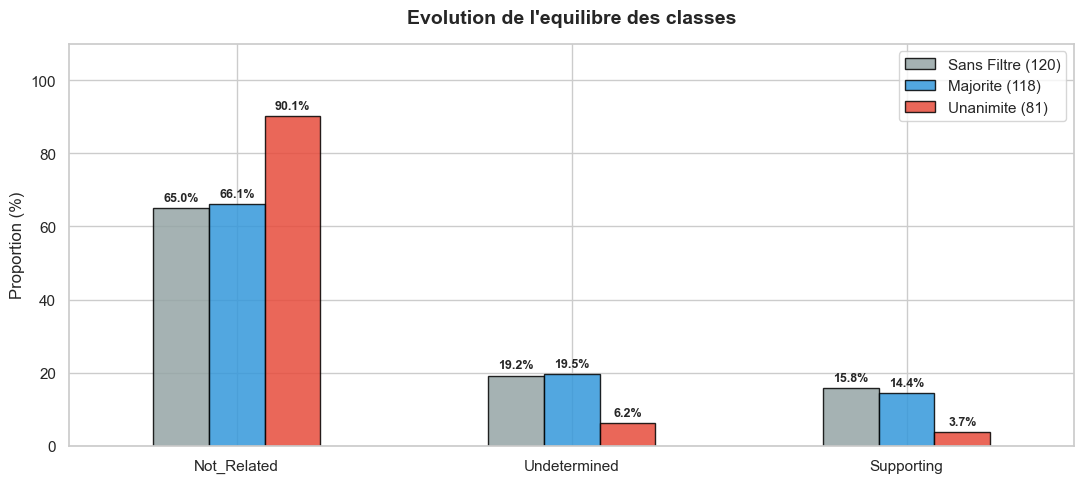

Generation des fichiers CSV finaux...
Fichiers CSV générés.
 Nombre de thematiques (topics) uniques : 13


,Thematique (Topic),Articles
0,Politics,60
1,National,14
2,Business,10
3,Local/Regional,6
4,International,5
5,Technology,4
6,Weather,4
7,Health,4
8,Science,4
9,Opinion/Editorial,3


In [3]:
rapport_filtres = simuler_filtre(dataset)

## Étape 4 : Gestion des Conflits (Feuille de route pour ré-annotation)
Plutôt que de faire repasser l'équipe sur tous les articles, 
cet algorithme isole spécifiquement les éléments problématiques (égalité parfaite 3-3, configuration 2-2-1, ou désaccord majeur <= 50%).
Il génère un fichier CSV d'action avec les textes complets pour la prochaine session d'annotation.

In [4]:
assigner_donnees(dataset)

 ALGORITHME D'ASSIGNATION (GESTION DES CONFLITS)
 Analyse terminée : 2 articles détectés pour ré-annotation.

 APERÇU DES TÂCHES À REDISTRIBUER :
Niveau_Priorite ID_Article    Topic  Votes_Actuels                                           Raison_Assignation
   P2 (Conflit)    ID 2_T1 Politics              4   Conflit majeur (Configuration 2-2). Ré-annotation requise.
   P2 (Conflit)    ID 5_T2 Politics              5 Conflit majeur (Configuration 2-2-1). Ré-annotation requise.

 Fichier 'feuille_de_route_reannotation.csv' enregistré avec TOUTES les colonnes de texte !


,Niveau_Priorite,ID_Article,Topic,Votes_Actuels,Max_Votes_Identiques,Raison_Assignation,ID_Ancre,Texte_Ancre,Cible,Texte_Cible
0,P2 (Conflit),ID 2_T1,Politics,4,2,Conflit majeur (Configuration 2-2). Ré-annotat...,ID 2,Higher costs and cramped conditions: the impac...,T1,Migration has been blamed for the housing cris...
1,P2 (Conflit),ID 5_T2,Politics,5,2,Conflit majeur (Configuration 2-2-1). Ré-annot...,ID 5,Tuning Out: Americans on the Edge of Politics ...,T2,"Views of American politics, polarization and t..."
